In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from IPython.display import display

# Read

In [4]:
# df = pd.read_parquet('/Users/krispred/Documents/capstone/datascience-capstone/data/processed/particle_labeled.parquet')
df = pd.read_parquet('../../../data/processed/particle_labeled.parquet ')

In [5]:
# df.head()

In [6]:
# for col in df.columns:
#     print(col, '\n')

In [7]:
# Table 1
element_cols = [c for c in df.columns if c not in [
    'stub_id', 'particle_id', 'relevance_class',
    'merged_relevance_class', 'final_class', 'label', 'target'
] and df[c].dtype in ['float64', 'int64']]

print(f"Particles: {len(df):,}")
print(f"Element features: {len(element_cols)}")

# build table 1
table_label_counts = (
    df['label']
      .value_counts()
      .rename_axis('Label')
      .reset_index(name='Count')
)
table_label_counts['Proportion'] = table_label_counts['Count'] / len(df)

styler = (
    table_label_counts.style
                      .format({'Count': '{:,.0f}', 'Proportion': '{:.1%}'})
                      .hide(axis='index')
                      .set_caption("Table 1: Label Distribution")
                      .set_table_styles([
                          {'selector': 'caption',
                           'props': [
                               ('caption-side', 'top'),
                               ('font-weight', 'bold'),
                               ('font-size', '1.05em'),
                               ('text-align', 'left')
                           ]}
                          ])
)

display(styler)

Particles: 2,801,667
Element features: 89


Label,Count,Proportion
Non_GSR,"1,216,039",43.4%
GSR,"1,078,946",38.5%
Ambiguous,"506,682",18.1%


# This data is sparse as most elemental cols are 0 (trees can handle this) but how sparse?

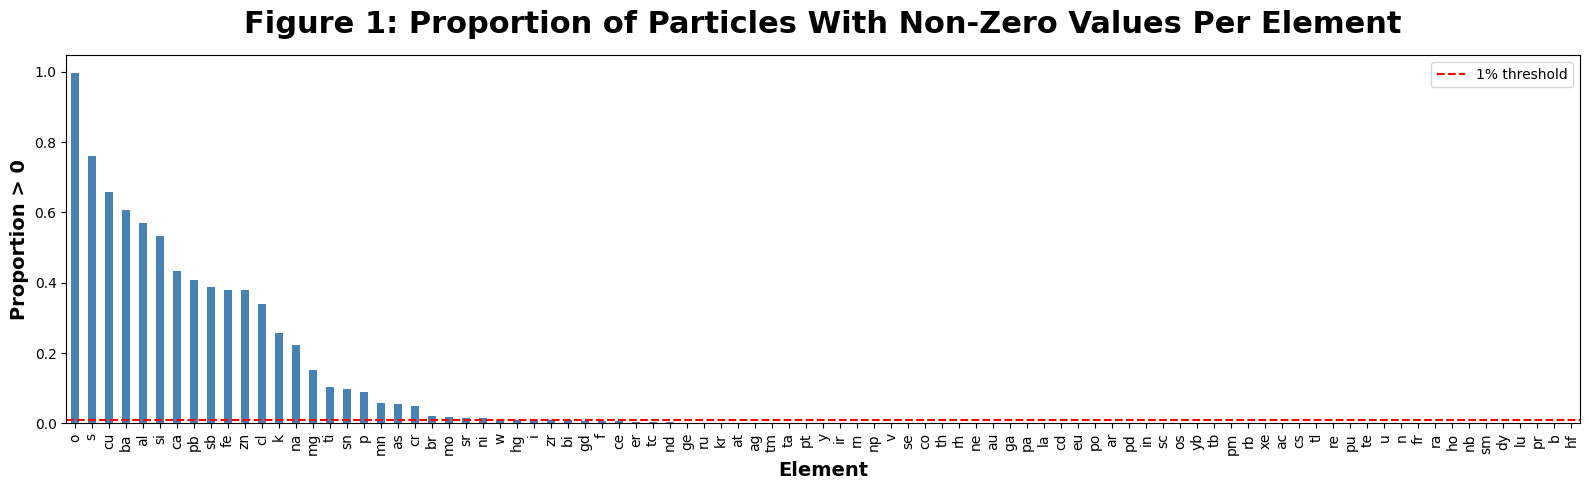

In [23]:
# Figure 1
nonzero_rates = (df[element_cols] > 0).mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(16, 5))
nonzero_rates.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Figure 1: Proportion of Particles With Non-Zero Values Per Element', fontsize=22, fontweight='bold', pad=16)
ax.set_ylabel('Proportion > 0', fontsize=14, fontweight='bold')
ax.set_xlabel('Element', fontsize=14, fontweight='bold')
ax.axhline(y=0.01, color='red', linestyle='--', label='1% threshold')
ax.legend()
plt.tight_layout()
#plt.savefig('figures/element_sparsity.png', bbox_inches='tight')
plt.show()

In [13]:
# Table 2
informative = nonzero_rates[nonzero_rates > 0.01].index.tolist()
sparse = nonzero_rates[nonzero_rates <= 0.01].index.tolist()

# build table 2
def cap_join(lst, n=10):
    return ', '.join(str(x).capitalize() for x in lst[:n])

table2 = pd.DataFrame({
    'Category': ['Informative (>1% non-zero)', 'Sparse (<=1% non-zero)'],
    'Count': [len(informative), len(sparse)],
    'Examples': [cap_join(informative), cap_join(sparse)]
})

styler = (
    table2.style
          .format({'Count': '{:,}'})
          .hide(axis='index')
          .set_caption("Table 2: Informative vs. Sparse Element Counts")
          .set_table_styles([
              {'selector': 'table',
               'props': [
                   ('border', '1px solid #444'),
                   ('border-collapse', 'collapse'),
                   ('width', '100%')
               ]},
              {'selector': 'th, td',
               'props': [
                   ('border', '1px solid #ccc'),
                   ('padding', '6px'),
                   ('vertical-align', 'top')
               ]},
              {'selector': 'caption',
               'props': [
                   ('caption-side', 'top'),
                   ('font-weight', 'bold'),
                   ('font-size', '1.05em'),
                   ('text-align', 'left')
               ]},
              {'selector': 'thead th', 'props': [('text-align', 'center')]},
              {'selector': 'td', 'props': [('white-space', 'normal')]}
          ]).set_properties(subset=['Category', 'Examples'], **{'text-align': 'left'})
)

display(styler)


Category,Count,Examples
Informative (>1% non-zero),27,"O, S, Cu, Ba, Al, Si, Ca, Pb, Sb, Fe"
Sparse (<=1% non-zero),62,"I, Zr, Bi, Gd, F, Ce, Er, Tc, Nd, Ge"


# What is the average elemental composition per particle? 

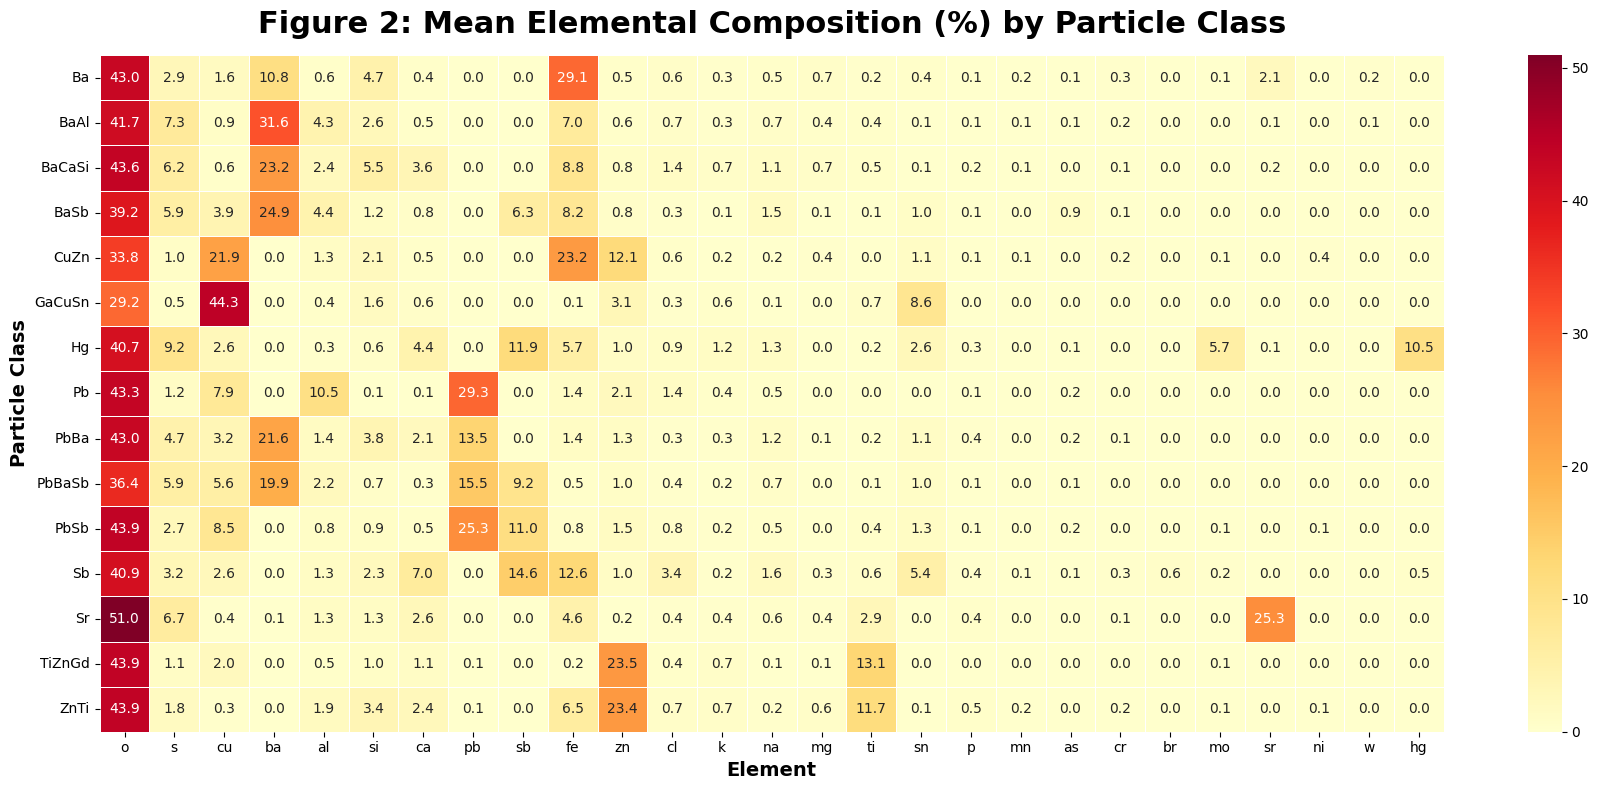

In [17]:
# Figure 2
class_means = df.groupby('final_class')[informative].mean()

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(class_means, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.5)
ax.set_title('Figure 2: Mean Elemental Composition (%) by Particle Class', fontsize=22, fontweight='bold', pad=16)
ax.set_ylabel('Particle Class', fontsize=14, fontweight='bold')
ax.set_xlabel('Element', fontsize=14, fontweight='bold')
plt.tight_layout()
#plt.savefig('figures/class_composition_heatmap.png', bbox_inches='tight')
plt.show()

# How balanced is our data?

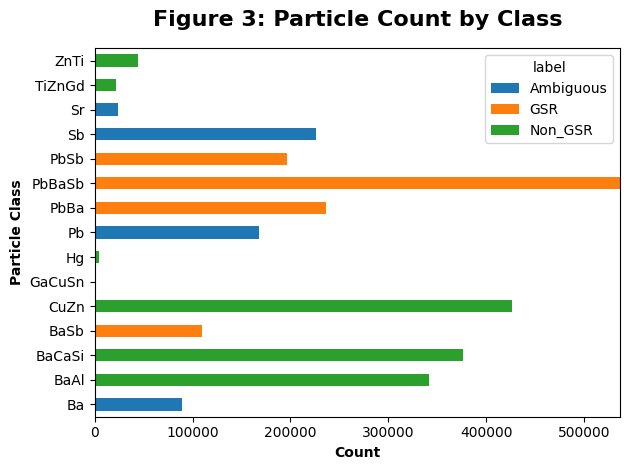

In [21]:
# Figure 3
class_counts = df.groupby(['final_class', 'label']).size().unstack(fill_value=0)

class_counts.plot(kind='barh', stacked=True)
plt.title('Figure 3: Particle Count by Class', fontsize=16, fontweight='bold', pad=16)
plt.ylabel('Particle Class', fontweight='bold')
plt.xlabel('Count', fontweight='bold')

plt.tight_layout()
#plt.savefig('figures/class_balance.png', bbox_inches='tight')
plt.show()

In [40]:
# Table 3
class_counts_stacked = df.groupby(['final_class', 'label']).size()
class_counts_stacked.sort_values(ascending=False, inplace=True)

# build table 3
table3 = (
    class_counts_stacked
      .rename('Particle Counts')
      .reset_index()
      .rename(columns={'final_class': 'Final Class', 'label': 'Label'})
)

styler = (
    table3.style
          .format({'Particle Counts': '{:,}'})
          .hide(axis='index')
          .set_caption("Table 3: Class Distribution with Labels")
          .set_table_styles([
              {'selector': 'table',
               'props': [
                   ('border', '1px solid #444'),
                   ('border-collapse', 'collapse'),
                   ('width', '100%')
               ]},
              {'selector': 'th, td',
               'props': [
                   ('border', '1px solid #ccc'),
                   ('padding', '6px'),
                   ('vertical-align', 'top')
               ]},
              {'selector': 'caption',
               'props': [
                   ('caption-side', 'top'),
                   ('font-weight', 'bold'),
                   ('font-size', '1.05em'),
                   ('text-align', 'left'),
                   ('padding-bottom', '0.4em')
               ]},
              {'selector': 'thead th', 'props': [('text-align', 'center')]},
              {'selector': 'th, td', 'props': [('padding', '6px')]}
          ])
          .set_properties(subset=['Final Class', 'Label'], **{'text-align': 'left'})
          .set_properties(subset=['Particle Counts'], **{'text-align': 'right'})
)

display(styler)

Final Class,Label,Particle Counts
PbBaSb,GSR,"536,634"
CuZn,Non_GSR,"426,015"
BaCaSi,Non_GSR,"375,875"
BaAl,Non_GSR,"341,756"
PbBa,GSR,"236,299"
Sb,Ambiguous,"225,676"
PbSb,GSR,"196,294"
Pb,Ambiguous,"168,334"
BaSb,GSR,"109,719"
Ba,Ambiguous,"89,277"


# How strong is the signal? 

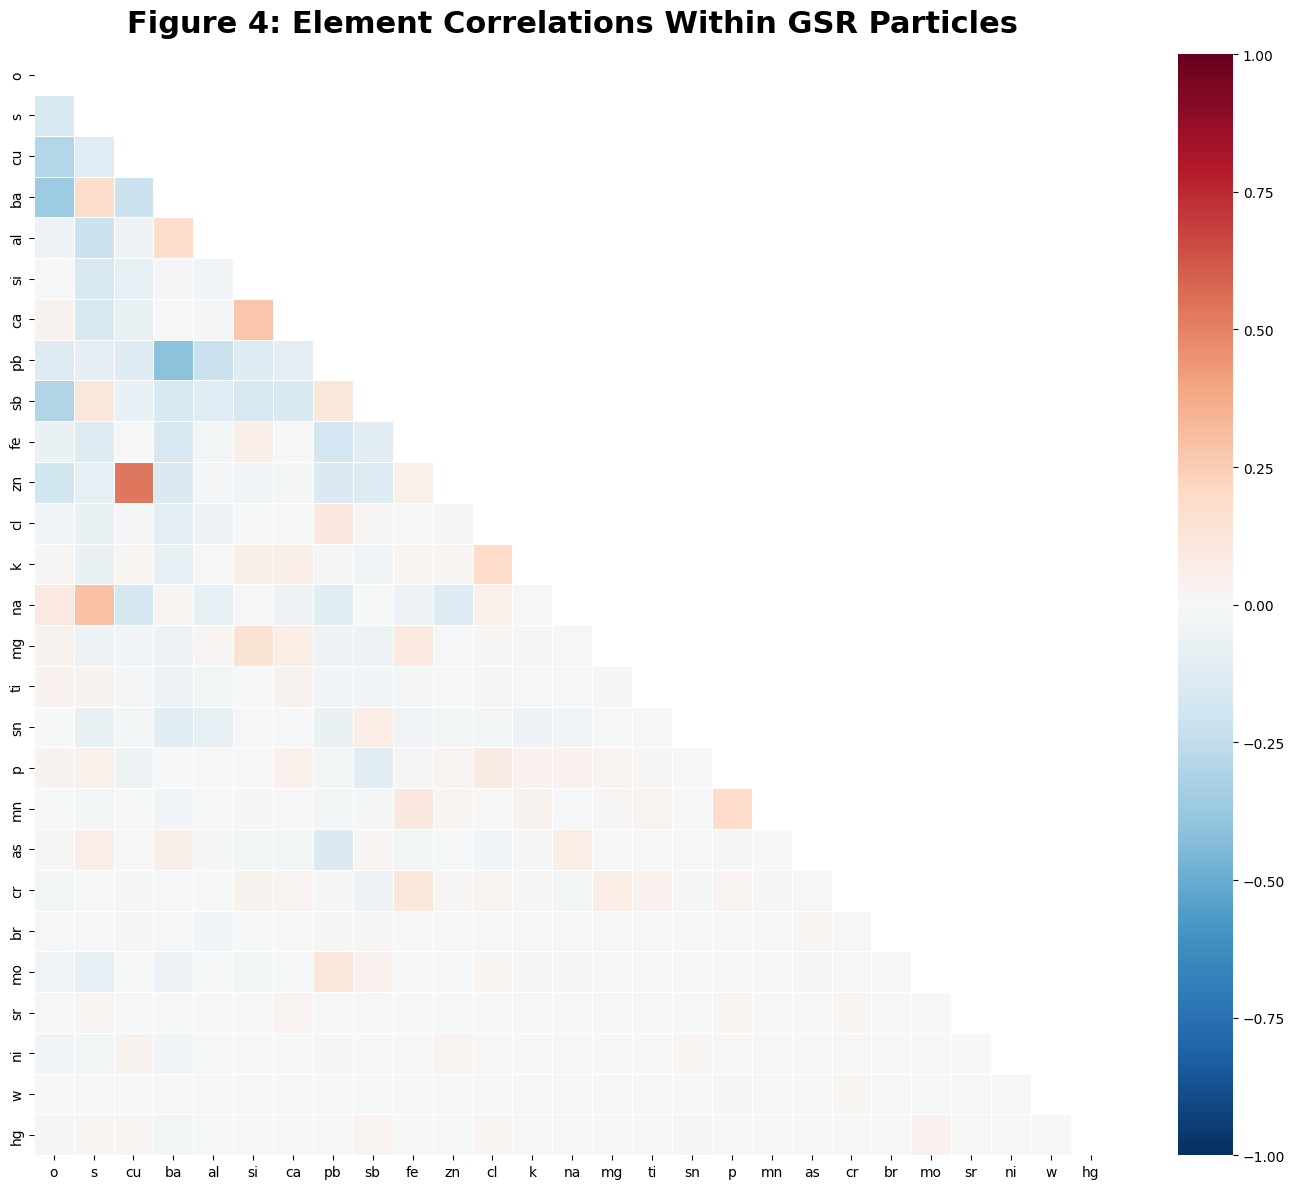

In [36]:
# Figure 4
gsr_only = df[df['label'] == 'GSR'][informative]

corr = gsr_only.corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=False, ax=ax, linewidths=0.5)
ax.set_title('Figure 4: Element Correlations Within GSR Particles', fontsize=22, fontweight='bold', pad=16)
plt.tight_layout()
#plt.savefig('figures/correlation_gsr.png', bbox_inches='tight')
plt.show()

In [46]:
# Table 4
corr_pairs = corr.where(~mask).stack().reset_index()
corr_pairs.columns = ['Element 1', 'Element 2', 'Correlation']
corr_pairs['abs_corr'] = corr_pairs['Correlation'].abs()
# build table 4
top_pairs = corr_pairs.sort_values('abs_corr', ascending=False).head(7)
table4 = top_pairs[['Element 1', 'Element 2', 'Correlation']].reset_index(drop=True)

styler = (
    table4.style
          .format({'Correlation': '{:.3f}'})
          .hide(axis='index')   # works for pandas 3.0.1
          .set_caption("Table 4: Strongest GSR Correlations")
          .set_table_styles([
              {'selector': 'table',
               'props': [
                   ('border', '1px solid #444'),
                   ('border-collapse', 'collapse'),
                   ('width', '100%')
               ]},
              {'selector': 'th, td',
               'props': [
                   ('border', '1px solid #ccc'),
                   ('padding', '6px'),
                   ('vertical-align', 'top')
               ]},
              {'selector': 'caption',
               'props': [
                   ('caption-side', 'top'),
                   ('font-weight', 'bold'),
                   ('font-size', '1.05em'),
                   ('text-align', 'left'),
                   ('padding-bottom', '0.4em')
               ]},
              {'selector': 'thead th', 'props': [('text-align', 'center')]},
              {'selector': 'th, td', 'props': [('padding', '6px')]}
          ])
          .set_properties(subset=['Element 1', 'Element 2'], **{'text-align': 'left'})
          .set_properties(subset=['Correlation'], **{'text-align': 'right'})
)

display(styler)


Element 1,Element 2,Correlation
zn,cu,0.535
pb,ba,-0.407
ba,o,-0.361
sb,o,-0.301
na,s,0.292
cu,o,-0.291
ca,si,0.280


# Is PCA helpful? We have sparse data so maybe not.

In [48]:
le = LabelEncoder()

In [49]:
binary = df[df['label'].isin(['GSR', 'Non_GSR'])]

In [50]:
class_encoded = le.fit_transform(binary['final_class'])

In [51]:
X_vis = binary[informative].fillna(0).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vis)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

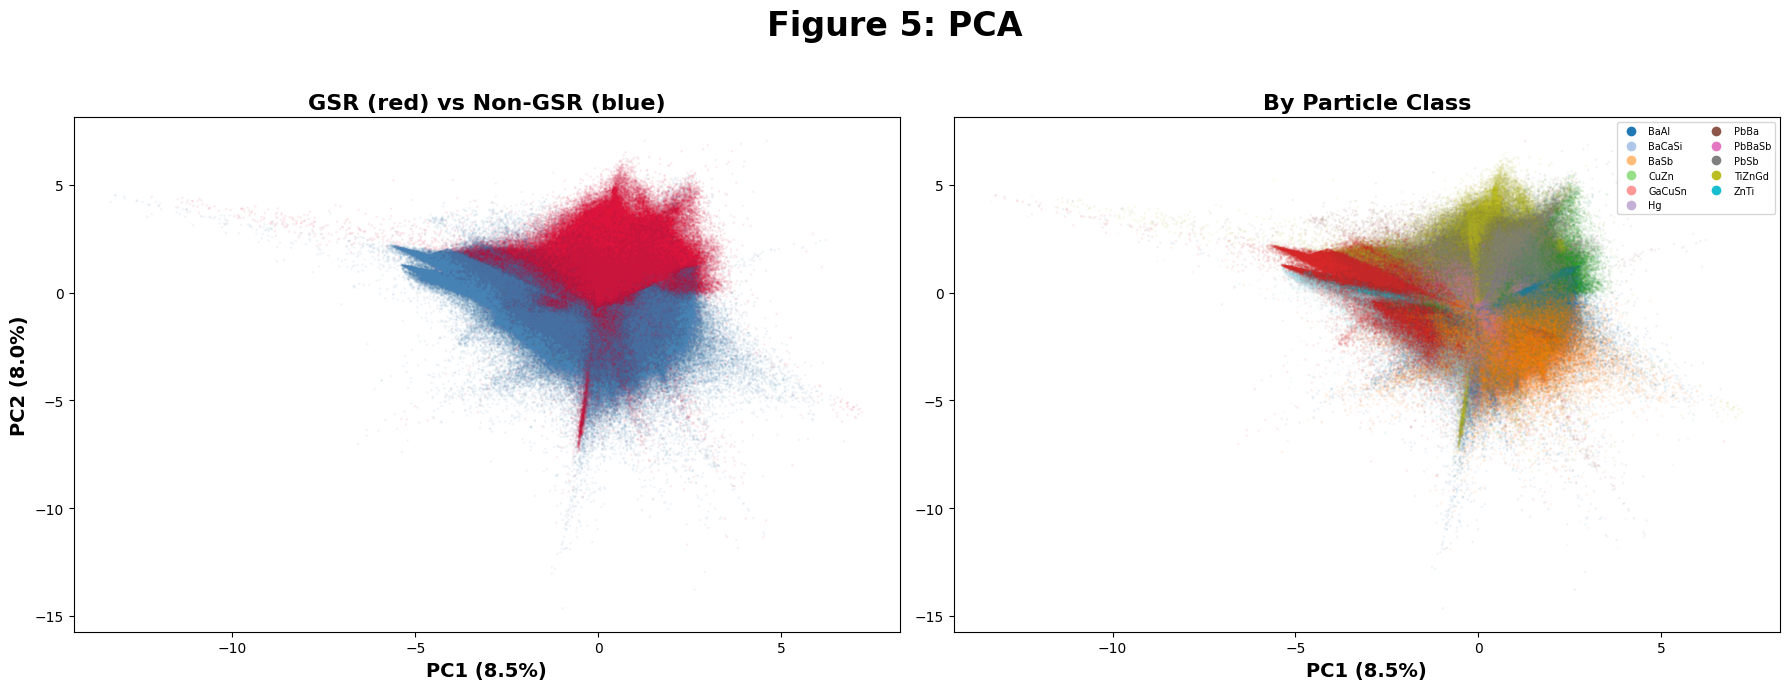

In [ ]:
# Figure 5
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

colors = binary['label'].map({'GSR': 'crimson', 'Non_GSR': 'steelblue'}).values
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.05, s=1)
axes[0].set_title('GSR (red) vs Non-GSR (blue)', fontsize=16, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=14, fontweight='bold')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=14, fontweight='bold')

scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=class_encoded,
                           cmap='tab20', alpha=0.05, s=1)
axes[1].set_title('By Particle Class', fontsize=16, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=14, fontweight='bold')

handles = [plt.Line2D([0], [0], marker='o', color='w',
           markerfacecolor=plt.cm.tab20(i / len(le.classes_)),
           markersize=8, label=cls)
           for i, cls in enumerate(le.classes_)]
axes[1].legend(handles=handles, loc='upper right', fontsize=7,
               ncol=2, markerscale=1)

#plt.savefig('figures/pca_visualization.png', bbox_inches='tight')

fig.suptitle('Figure 5: PCA',
             fontsize=24, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [55]:
# Table 5
table5 = pd.DataFrame({
    'Component': ['PC1', 'PC2', 'Total (PC1 + PC2)'],
    'Variance Explained': [0.085, 0.080, 0.165]
})

# styling for Jupyter
styler = (
    table5.style
          .format({'Variance Explained': '{:.1%}'})
          .hide(axis='index')
          .set_caption("Table 5: PCA Variance Explained")
          .set_table_styles([
                {'selector': 'table',
                 'props': [
                      ('border', '1px solid #444'),
                      ('border-collapse', 'collapse'),
                      ('width', '50%')
                 ]},
                  {'selector': 'th, td',
                'props': [
                     ('border', '1px solid #ccc'),
                     ('padding', '6px'),
                     ('vertical-align', 'top')
                ]},
              {'selector': 'caption',
               'props': [
                   ('caption-side', 'top'),
                   ('font-weight', 'bold'),
                   ('font-size', '1.05em'),
                   ('text-align', 'left'),
                   ('padding-bottom', '0.4em')
               ]},
              {'selector': 'thead th', 'props': [('text-align', 'center')]},
              {'selector': 'th, td', 'props': [('padding', '6px')]}
          ])
          .set_properties(subset=['Component'], **{'text-align': 'left'})
          .set_properties(subset=['Variance Explained'], **{'text-align': 'right'})
)

display(styler)

Component,Variance Explained
PC1,8.5%
PC2,8.0%
Total (PC1 + PC2),16.5%


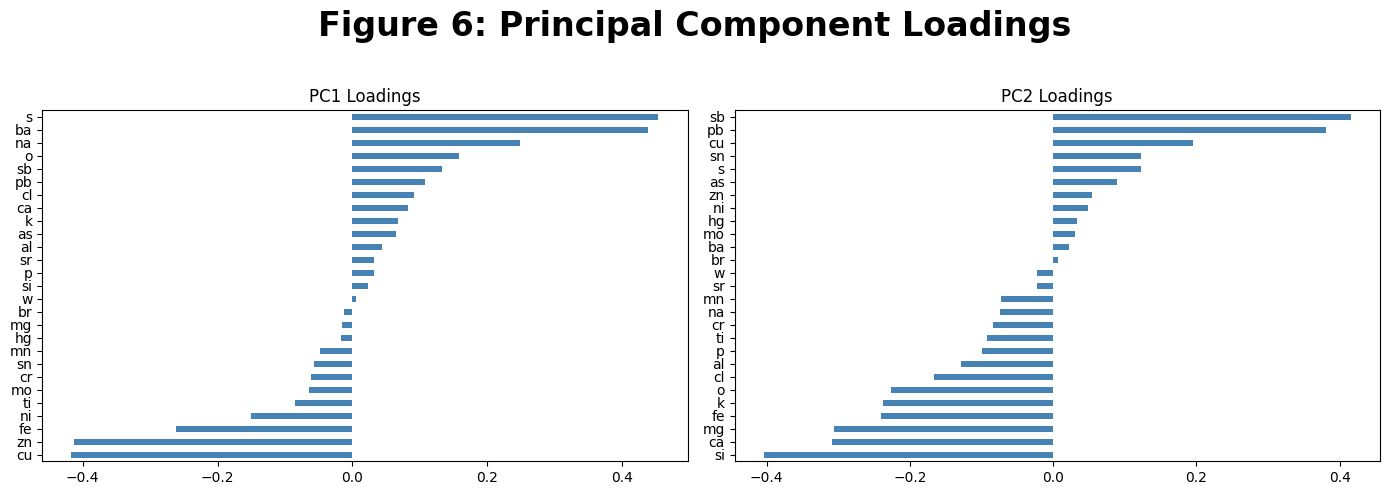

In [54]:
# Figure 6
# PCA loadings: which elements define the principal components?
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=informative
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
loadings['PC1'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('PC1 Loadings')
loadings['PC2'].sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('PC2 Loadings')
# plt.tight_layout()
#plt.savefig('figures/pca_loadings.png', bbox_inches='tight')
fig.suptitle('Figure 6: Principal Component Loadings',
             fontsize=24, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# What is up with the ambiguous particles? Is there clear separation? 

In [56]:
ambiguous = df[df['label'] == 'Ambiguous']
X_amb = scaler.transform(ambiguous[informative].fillna(0).values)
X_amb_pca = pca.transform(X_amb)

C:\Users\bkoco\AppData\Local\Temp\ipykernel_25884\1618407585.py:21: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout(rect=[0, 0, 1, 0.95])
c:\git\datascience-capstone\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


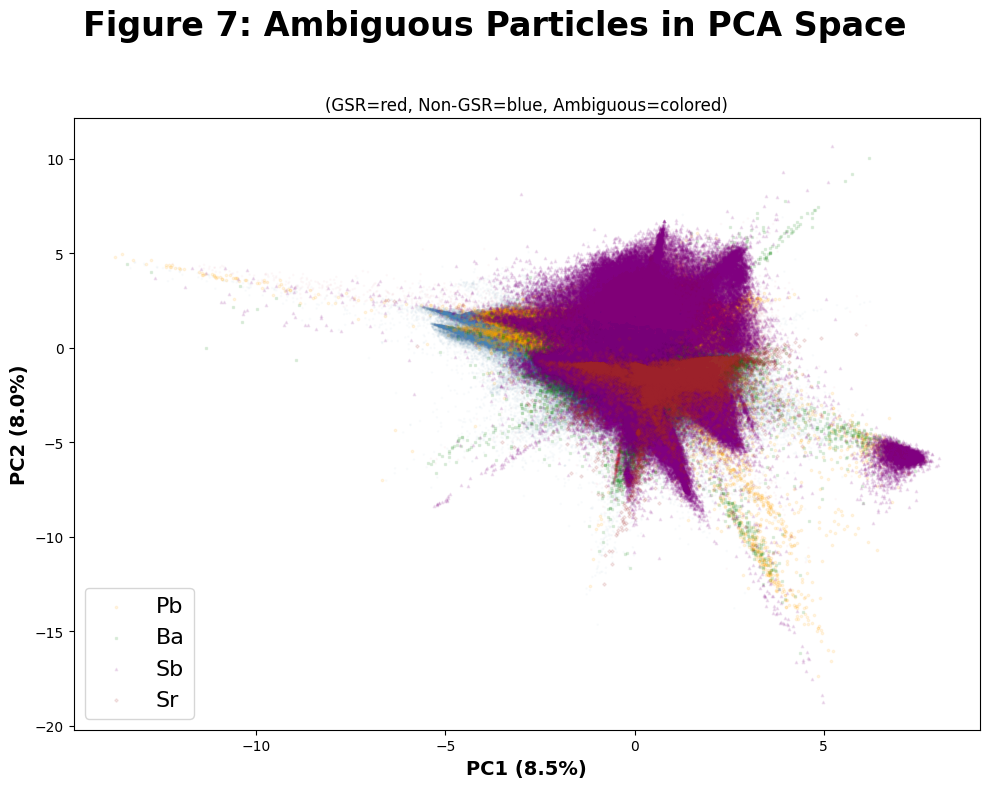

In [57]:
# Figure 7
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.02, s=1)

for cls, color, marker in [('Pb', 'orange', 'o'), ('Ba', 'green', 's'),
                            ('Sb', 'purple', '^'), ('Sr', 'brown', 'D')]:
    mask = ambiguous['final_class'] == cls
    if mask.sum() > 0:
        ax.scatter(X_amb_pca[mask, 0], X_amb_pca[mask, 1],
                   c=color, s=3, alpha=0.1, label=cls, marker=marker)

ax.legend(fontsize=16)
ax.set_title('(GSR=red, Non-GSR=blue, Ambiguous=colored)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=14, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=14, fontweight='bold')
# plt.tight_layout()
#plt.savefig('figures/pca_ambiguous.png', bbox_inches='tight')
fig.suptitle('Figure 7: Ambiguous Particles in PCA Space',
             fontsize=24, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Summary Stats

In [38]:
print(f"\nPCA variance explained: PC1={pca.explained_variance_ratio_[0]:.1%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.1%}")


PCA variance explained: PC1=8.5%, PC2=8.0%


### Interpretation
PC1 and PC2 together explain only 16.5% of variance (8.5% + 8.0%). The scatter plots show substantial overlap between GSR and Non-GSR particles in the reduced space.

This has important implications:
- Linear models (logistic regression) will struggle as there's no clean linear separation
- High-dimensional feature space is necessary and dimensionality reduction loses critical information